In [1]:
import numpy as np
import matplotlib.pyplot as plt
import RandomForestcpp
from data_loader import SP500Loader

In [2]:
loader = SP500Loader(start_date="2010-01-01", end_date="2023-12-31")
df = loader.fetch_data()

Téléchargement des données ^GSPC...


In [3]:
X, y = loader.prepare_features_targets(df)
print(f"Données prêtes: {X.shape[0]} échantillons avec {X.shape[1]} features.")

Données prêtes: 3501 échantillons avec 10 features.


In [4]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

rf = RandomForestcpp.RandomForest(
        n_trees=500, 
        max_depth=20, 
        min_samples_split=10,
        task_type=RandomForestcpp.TaskType.REGRESSION
    )

In [5]:
rf.fit(X_train, y_train)

In [6]:
print("Prédiction sur le jeu de test...")
predictions = rf.predict(X_test)
predictions = np.array(predictions)
predictions = predictions.flatten() # Assurance que c'est bien 1D

# Reconstruction des prix (car le modèle prédit maintenant les rendements)
# X_test[:, 0] correspond à la feature 'Close' (prix du jour J)
last_close_prices = X_test[:, 0]

predicted_prices = last_close_prices * (1 + predictions)
real_prices = last_close_prices * (1 + y_test)

# Évaluation (RMSE sur les prix reconstruits)
rmse = np.sqrt(np.mean((predicted_prices - real_prices)**2))
print(f"RMSE sur le prix reconstruit: {rmse:.4f}")

Prédiction sur le jeu de test...
RMSE sur le prix reconstruit: 50.3906


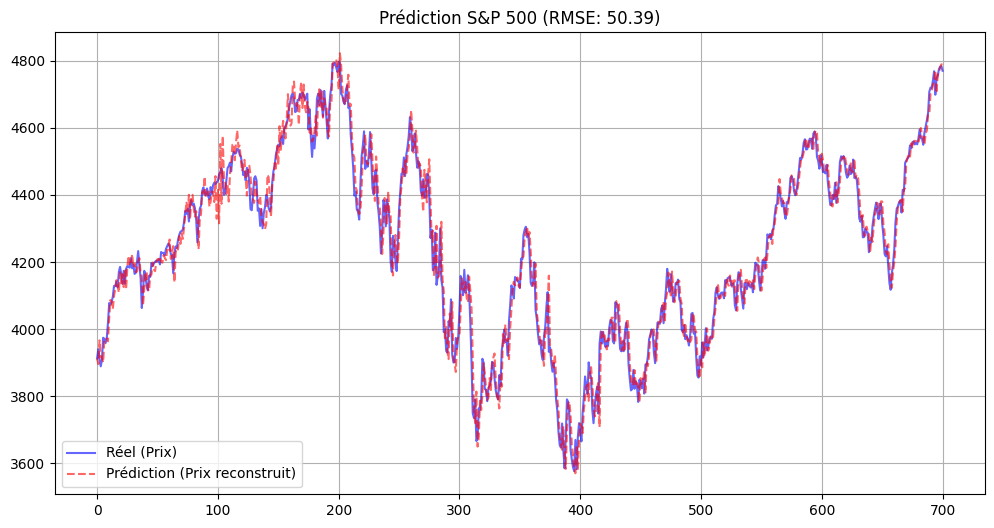

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(real_prices, label='Réel (Prix)', color='blue', alpha=0.6)
plt.plot(predicted_prices, label='Prédiction (Prix reconstruit)', color='red', alpha=0.6, linestyle='--')
plt.title(f'Prédiction S&P 500 (RMSE: {rmse:.2f})')
plt.legend()
plt.grid(True)
plt.show()